In [26]:
# Import all necessary libraries
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib
from pylab import *
import numpy as np
import random

%matplotlib inline

In [27]:
# Seed usada para ter os mesmos númeos aleatorios
np.random.seed(1234)

In [28]:
# Numeros de exemplos, a serem utilizados
N = 1000

In [29]:
# Input values (features), gera uma matriz de 1000 linhas e 1 coluna, Gera 1000 números aleatórios uniformes entre 0 e 1 depois multiplica por 10.
x1 = 10.0*np.random.rand(N, 1)

# True function, calucla o valor de y sem ruído, funçã real que queremos aprender.
y = 2.0*x1

# Aqui adiciona ruído à saída y, para simular dados do mundo real, np.random.randn gera valores com distribuição norlma(média 0 e desvio padrão 1).
# Output values (targets).
y_noisy = y + 10.0*np.random.randn(N, 1)

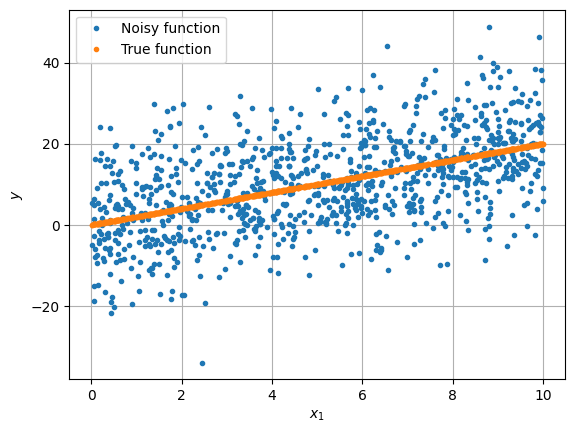

In [30]:
# cria a figura do gráfico, como se abrisse uma tela em branco
fig = plt.figure()

# plotando x1 com os valores de ruído, cada ponto é um aentrada x1, com ruído
plt.plot(x1,y_noisy,'.', label='Noisy function')

# plolta a função perfeita (y = 2*x1) também com pontos ('.'), aparece uma linha reta feita de pontos - pq é a relação exata sem erro
# os pontos de y_noisy vão estar espalhados ao redor da reta, por causa do ruído
# isso ajuda a ver como o ruído afeta os dados e pq regressão linear precisa achar a reta que melhor passa no meio desssa nuvem
plt.plot(x1,y,'.', label='True function')


plt.xlabel('$x_1$') #nome do eixo x
plt.ylabel('$y$') #nome do eixo y
plt.legend()  #mostrar legenda com nomes das curvas
plt.grid() # grade no fundo
plt.show() #mostra o grafico

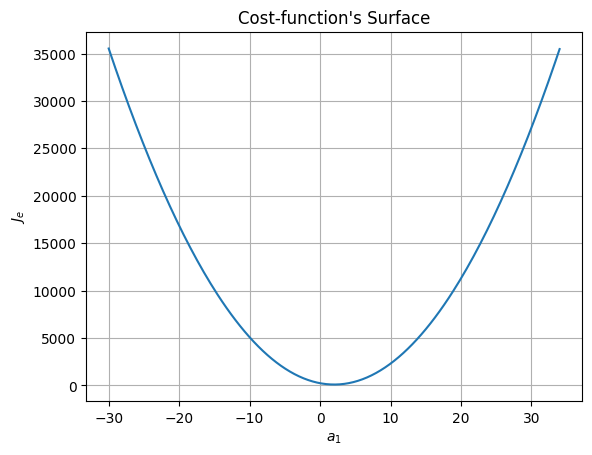

In [31]:
# Objetivo desse codigo, testando valores diferentes de a1 (coeficiente da reta ) para ver como o erro muda. A ideia é vizualizar a função de custo

# Generate values for parameters,  crriando 200 valores de a1 igualmente espaçados entre -30 e 34.
M = 200
A1 = np.linspace(-30.0, 34.0, M)

# Generate points for plotting the cost-function surface.
# J = np.zeros((M)), cria um vetor para guardar o valor da função de custo Je, para cada um dos 200 valores de a1
J = np.zeros((M))

# para cade iteraçao, para cada a1 calcula-se a reta predita: yhat = a1*x1
# cálcula o MSE, e guarda o resulttado em J[iter1]
for iter1 in range(0, M):
    yhat = A1[iter1]*x1
    J[iter1] = (1.0/N)*np.sum(np.square(y_noisy - yhat));

# Plot cost-function surface.
# o ponto mais baixo da curva é o mellhor valor de a1, onde o erro é minimo
fig = plt.figure()
plt.plot(A1, J)
plt.xlabel('$a_1$') # valores testados de a1
plt.ylabel('$J_e$') # custo J(a1)
plt.title('Cost-function\'s Surface')
plt.grid()
#Show the plot.
plt.show()

In [32]:
# Closed-form solution(solução de forma fechada). Calcular o valor ótimo de a1 diretamente
# a formula para a solução é: a1 = (X^TX)^-1*X^Ty
# X é a matriz de entradas x1, e y é o vetor de saídas y_noisy
# X^T é a trasponsta da matriz X
# (X^TX)^-{1} é a inversa de X^T*X, oq nos da a solução exata para a1

# np.transpose(x1) -> Calcula a transposta de X1, se X1 for um vetor coluna, essa operação transforma em um linha
# np.transpose(x1).dot(x1) -> calcula o produto de X1^T (transposta de X1) com X1,ou seja X^T*X
# np. linalg.piv() -> Calcula a pseudo-inversa de X^T*X. A pseudo inversa é usada quando a matriz não é invertivel diretamente (por exemplo, quando ela não é quadrada ou não tem uma inversa). Isso resolve problemas numéricos em vez de usar a inversa direta.
# np.transpose(x1).dot(y_noisy) -> Calcula o produto entre X1^T (transposta de X1) e o vetor de valores reais ynoisy
# a1_opt -> Multiplicando a pseudo-inversa de X^T*X por X^T y, obtemoso valor ótimo de a1, que é a solução para o modelo de regressao linear
a1_opt = np.linalg.pinv(np.transpose(x1).dot(x1)).dot(np.transpose(x1).dot(y_noisy))

# Calculando o erro ótimo, depois de encontrar o a1_opt
# aqui usa o valor ótimo de a1 para calcular as previsões yhat, ou seja, a reta predita pela regressão linear
yhat = a1_opt*x1

# np.power((y_noisy - yhat), 2), calcula o erro quadratico para cada pondo de dados, diferença entre os valores reais (y_noisy) e os valores predito (yhat) elevada ao quadrado
# np.sum() soma todos os erros quadrados de todos os pontos
# (1.0/N) divide pela quantidade de pontos N para obter o erro medio
# Joptimum sera o valor do erro quadratico medio para o valor orimo de a1

Joptimum = (1.0/N)*np.sum(np.power((y_noisy - yhat), 2))

print(Joptimum)

99.43362282057217


In [33]:
# Gradient-descent solution.
maxNumIter = 10000 #Numero maximo de iteraçoes, que o gradiente descendente vai fazer

alpha = 0.01 #taxa de aprendizado (quanto o valor de a1 sera ajustado a cada iteraçaão)

# Create empty structures.
a1_hist = np.zeros((maxNumIter)) # Vetor que vai armazenar os valores de a₁ a cada iteração.
Jgd = np.zeros(maxNumIter) #Vetor que vai armazenar os valores da função de custo (erro) a cada iteração.

#valor inicial de a1
a1 = -30
# Armazenando o valor inicial de 'a1' em 'a1_hist'
a1_hist[0] = a1

# alcula as previsoes (yhat) para o valor inicial de a1
yhat = a1*x1


# A funçaõ de custo é calculada com o valor a1 inicial, armazenando o MSE
Jgd[0] = (1.0/N)*np.sum(np.power(y_noisy - yhat, 2))

error = 1 # Inicializa o erro para a condição de parada, controla o criterio de parada.  O loop continua até que o erro seja suficientemente pequeno (menor que 0.0001) ou até que o número máximo de iterações seja atingido.
iteration = 0 #inicializa o contador de iteração
while(error > 0.0001 and iteration < maxNumIter-1):

    h = a1*x1 #previsoes para o valor atua de 'a1'

    update = -(2.0/N)*x1.T.dot(y_noisy - h) # Aqui calcula o gradiente(derivada da função de custo). Indica a direção que o valor de a1 deve ser ajustado para diminuir o erro. A derivada é = -2/N sum(y_noisy-yhat)*x1

    # atualiza o valor de a1 subtraindo a correção alpha*update da previsao atual de a1. Essa atualização move a1 na direção que minimiza a função9 de custo
    a1 = a1 - alpha*update

    # armazena o valor de a1 no vetor a1_hist
    a1_hist[iteration+1] = a1
    # calcula as novas previsões com o valolr atualizado de a1
    yhat = a1*x1

    # Calcula e armazena a nova funçaõ de custo para o valor de a1 atualizadp
    Jgd[iteration+1] = (1.0/N)*sum(np.power(y_noisy - yhat, 2))

    # Jgd[iteration]-Jgd[iteration+1] Calcula a diferença absoluta entre a função de custo da iteração atual e a da próxima iteração.
    # é a quantidade de mudança no erro de uma iteração para a proxima
    # Se a diferença (error) for pequena: Isso significa que a função de custo não está mudando muito de uma iteração para outra. Ou seja, o algoritmo está se aproximando de um mínimo, e o erro está começando a estabilizar. Nesse caso, o algoritmo provavelmente atingiu um ponto de convergência e não há mais grandes melhorias no valor de 𝑎1.Se a diferença (error) for grande: Isso significa que o erro ainda está mudando muito entre as iterações, o que indica que o algoritmo ainda não convergiu para a solução ideal.

    error = np.abs(Jgd[iteration]-Jgd[iteration+1])
    #incrementa o numero de iteraçoes
    iteration += 1

<ipython-input-33-6d6cda6600cf>:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a1_hist[iteration+1] = a1


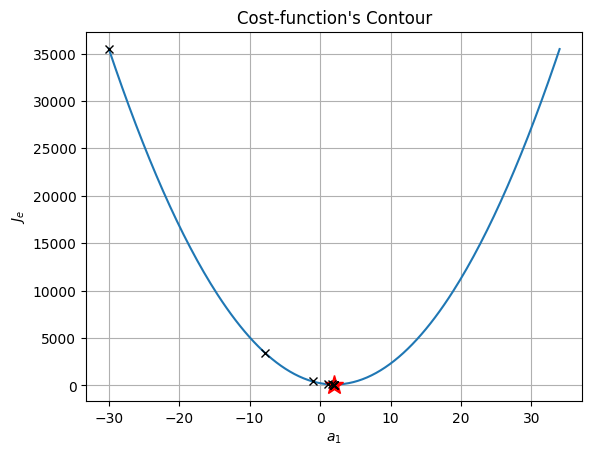

In [34]:
# criando a pagina em branco para o grafico
fig = plt.figure()

# Plotando a função de custo em relação aos valores de a1. . Isso mostra como a função de custo varia conforme o valor de 𝑎1é alterado, permitindo que você veja o formato da curva da função de custo.
plt.plot(A1, J)
plt.xlabel('$a_1$')
plt.ylabel('$J_e$')
plt.title('Cost-function\'s Contour')

#Aqui, você está plotando o ponto ótimo da função de custo (a1 obtido pela solução exata) no gráfico. Encontrado pela solução fechada, ponto marcado com um *
# a1_opt[0] Embora o valor calculado de a1  seja escalar, o a1_opt é provavelmente um vetor (mesmo que de dimensão 1x1, ainda é um vetor). Para garantir que você pegue o valor escalar, você usa a1_opt[0] para acessar o primeiro (e único) elemento do vetor. Ou seja, você pega o valor de a1​ diretamente.
plt.plot(a1_opt[0], Joptimum, c='r', marker='*', markersize=14)

# Aqui, você está plotando a trajetória de a1 durante o processo de gradiente descendente. Os valores de a1 são armazenados em a1_hist, e os valores da função de custo para cada iteração são armazenados em Jgd.
plt.plot(a1_hist[0:iteration], Jgd[0:iteration], 'kx')
plt.grid()
plt.show()

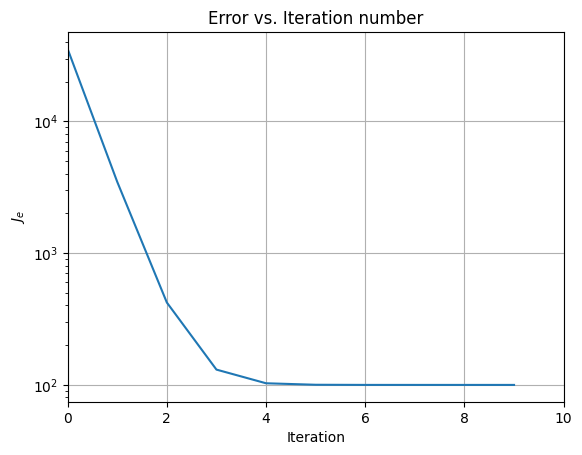

In [37]:
# plotando o erro ao longo das iterações
# Esse gráfico vai mostrar como a função de custo diminui à medida que o algoritmo de gradiente descendente ajusta o parâmetro a1.
fig = plt.figure()

# np.arrage(0,iteration), gera um vetor de números inteiros começãndo de 0 até o valor de iteração, que representa o numero de iterações realizadas.
# Jdg[0:iteration], pega os valores de Je (a função de custo) ao longo das iterações, até o número de iterações especificadas. O vetor Jdg contem o valor da função de custo para cada iteração
plt.plot(np.arange(0, iteration), Jgd[0:iteration])

#Aqui, você está definindo o limite do eixo x para que o gráfico mostre as iterações de 0 até o número total de iterações, ou seja, o gráfico vai ter como base o número total de iterações do algoritmo.
plt.xlim((0, iteration))

# alterando a escala para logaritimica,  A escala logarítmica ajuda a visualizar melhor a progressão do erro, pois ela diminui de maneira mais uniforme.
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('$J_e$')
plt.title('Error vs. Iteration number')
plt.grid()
plt.show()

In [36]:
print('a_opt: ' + str(a1_opt[0][0]))
print('a_gd: ' + str(a1[0][0]))


# ap proximidade entre a_opt e a_gd indica que o gradiente descendente foi bem-sucedido em converger para o valor correto, mesmo sem usar uma solução analítica

a_opt: 2.0127845339946164
a_gd: 2.01253417436744
